support vector machine demo

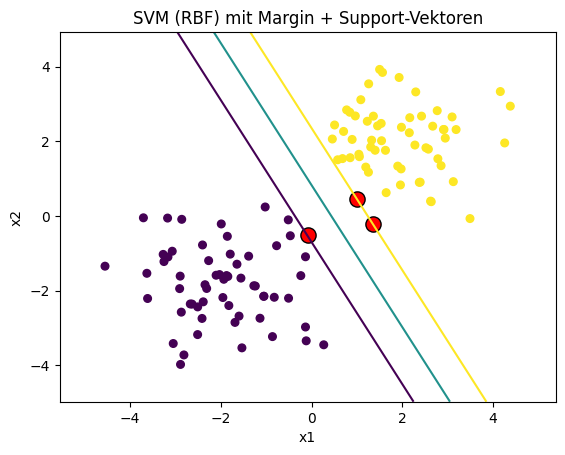

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Beispiel-Daten (ersetze das durch deine X, y)
np.random.seed(0)
X = np.r_[np.random.randn(60, 2) - [2, 2],
          np.random.randn(60, 2) + [2, 2]]
y = np.r_[np.zeros(60), np.ones(60)]

# Modell
clf = SVC(kernel="linear", C=1.0, gamma="scale")  # probier auch kernel="linear"
clf.fit(X, y)

def plot_svm(ax, clf, X, y, title="SVM"):
    # Punkte
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30)
    
    # Grid für Hintergrund/Entscheidungsfunktion
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # decision_function: Vorzeichen = Klasse, Betrag = "Abstand" zur Grenze (skaliert)
    Z = clf.decision_function(grid).reshape(xx.shape)

    # Entscheidungsgrenze (0) und Margins (-1, +1)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1])
    
    # Support Vektoren markieren
    sv = clf.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none', edgecolors='k')

    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

fig, ax = plt.subplots()
plot_svm(ax, clf, X, y, title="SVM (RBF) mit Margin + Support-Vektoren")
plt.show()
